In [2]:
### imports...
import numpy as np
import matplotlib.pyplot as plt
import statistics

In [3]:
### basic work for paper tables wrt dataset size
layer_res = [30, 30, 30, 30, 30, 30, 30, 30, 800, 800, 800, 800, 800, 800, 1000, 70, 70, 1000]
pyr_x = np.array([34, 34, 34, 34, 34, 34, 34, 34, 2, 2, 2, 2, 2, 2, 1, 15, 15, 1])
cube_x = np.array([34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 15, 15, 1])
old_adj_x = np.array([24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 15, 15, 1])
adj_x = np.array([25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 15, 15, 1])
y_sum = np.sum(np.array([15, 15, 1]) ** 2)

In [4]:
params_pyr = np.sum(pyr_x ** 2)
params_cube = np.sum(cube_x ** 2)
params_adj = np.sum(adj_x ** 2)
params_old = np.sum(old_adj_x ** 2)

In [5]:
print(params_pyr)
print(params_cube)
print(params_adj)
print("***")
print(params_pyr - y_sum)
print(params_cube - y_sum)
print(params_adj - y_sum)
print("***")
print(1 - (params_pyr/params_cube))

9724
17791
9826
***
9273
17340
9375
***
0.4534315103142038


In [6]:
### overhead and storage cost graph
gb_pyr = 3.86
gb_cube = 7.06
gb_adj = (params_adj / params_old) * 3.61

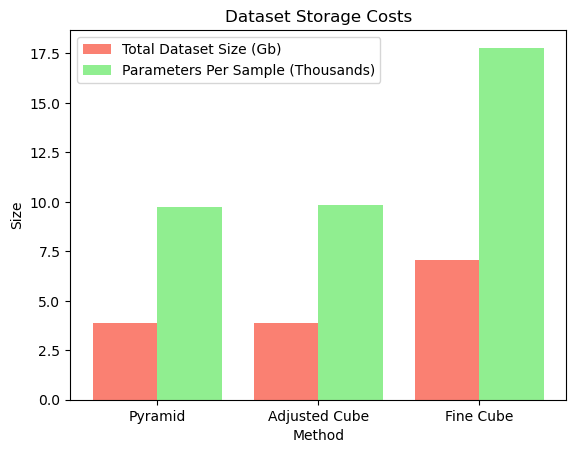

In [7]:
names = ["Pyramid", "Adjusted Cube", "Fine Cube"]
index = np.array([1, 2, 3])
fig, ax = plt.subplots()
disk = ax.bar(index-0.5, [gb_pyr, gb_adj, gb_cube], 0.4, color="salmon")
disk = ax.bar(index-0.1, [params_pyr/1000, params_adj/1000, params_cube/1000], 0.4, color="lightgreen")

ax.set_xticks(index-0.3, names)
ax.set_title("Dataset Storage Costs")
ax.legend(loc='upper left', labels=["Total Dataset Size (Gb)", "Parameters Per Sample (Thousands)"])
ax.set_ylabel('Size')
ax.set_xlabel('Method')

plt.savefig("data_cost_figs/storage_cost.png")

In [8]:
### work on graph for overhead time cost

In [15]:
### ok -- now compile results for model performance table...
import pickle

models_locs = [["../models/trained/c2_late_a_pyramid", "model_cascade_late_a_pyramid_16x3"]]
###models_locs = [["../models/trained/c2_early_b_pyramid", "model_cascade_early_b_pyramid_16x3_0"],
###               ["../models/trained/c2_mid_cube", "model_cascade_mid_cube_16x3_0"]]
"""               ["../models/trained/c2_early_cube", "cascade_early_cube_8x3"],
               ["../models/trained/c2_early_adjust", "ccascade_early_adjust_8x3"],
               ["../models/trained/c2_mid_pyramid", "cascade_mid_pyramid_8x3"],
               ["../models/trained/c2_mid_cube", "cascade_mid_cube_8x3"],
               ["../models/trained/c2_mid_adjust", "cascade_mid_adjust_8x3"],
               ["../models/trained/c2_late_a_pyramid", "cascade_late_a_pyramid_8x3"],
               ["../models/trained/c2_late_a_cube", "cascade_late_a_cube_8x3"],
               ["../models/trained/c2_late_a_adjust", "cascade_late_a_adjust_8x3"],
               ["../models/trained/multi_vit_pyramid", "multiscale_vit_pyramid_8x3"],
               ["../models/trained/multi_vit_cube", "multiscale_vit_cube_8x3"],
               ["../models/trained/multi_vit_adjust", "multiscale_vit_adjust_8x3"]]"""


on_folds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [16]:
### load metrics pickles
models_metrics = []
for i in range(len(models_locs)):
    print(models_locs[i][0] + "/metrics.txt")
    with open(models_locs[i][0] + "/metrics.txt", "rb") as metrics_log:
        models_metrics.append(pickle.load(metrics_log))

../models/trained/c2_late_a_pyramid/metrics.txt


In [17]:
### organization: [metric_type, ylayer, fold]
y_layer_names = ["wue", "esi", "agb"]
print(models_metrics[0]["train"]["time"])
for i in range(len(models_metrics)):
    for j in range(3):
        foldmse = []
        for k in range(len(on_folds)):
            foldmse.append(np.mean(models_metrics[i]["val"]["mse_single"][j][k]))
            print(foldmse[k])
        print(models_locs[i][0], "--", y_layer_names[j] + "_mse mean", np.mean(foldmse), 
              "   std", np.std(foldmse), "   (" + str(len(foldmse)) + " samples)")
    print(models_locs[i][0], "--", "time mean", np.mean(models_metrics[i]["train"]["time"]), "   std",
          np.std(models_metrics[i]["train"]["time"]))
    print("**")

[21308.650594, 21295.699431, 21250.026173, 21247.929701, 20978.101358, 21129.104913000003, 21244.869483999995, 21216.560648999992, 21125.720880000008, 21136.282548999996]
../models/trained/c2_late_a_pyramid -- wue_mse mean 0.0005870338204285989    std 0.0002798042221960934    (10 samples)
../models/trained/c2_late_a_pyramid -- esi_mse mean 0.006513299699977393    std 0.0024098442835778187    (10 samples)
../models/trained/c2_late_a_pyramid -- agb_mse mean 0.006297185490822981    std 0.001522160468426421    (10 samples)
../models/trained/c2_late_a_pyramid -- time mean 21193.2945732    std 95.62610888735846
**


In [11]:
### load data and do distribution graph ... imports
sys.path.append("..")
from models.data_handler import data_wrangler



2024-09-26 15:42:24.005937: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [21]:
### load wrangler
metadata_cols = []
with open("../data/ml_sets/pyramid_lf22/" + "info.txt", 'r') as infofile:
    metadata_total = infofile.read().replace('\n', ';')
metadata_lines = metadata_total.split(";")
metadata = []
for metal in metadata_lines:
    if len(metal) > 0:
        metadata.append(metal.split(","))

other_info = metadata.pop(0)
other_info = {"n_folds": other_info[0], "buffer_nodata": other_info[1], "base_crs": other_info[2],
                }
n_layers = len(metadata)
layer_info = {"layer_dims": [], "x_layers": [], "y_layers": [], "layer_names": []}

for j in range(n_layers):
    layer_info["layer_dims"].append(int(metadata[j][0]))
    layer_info["layer_names"].append(metadata[j][3])
    if metadata[j][1] == "x":
        layer_info["x_layers"].append(j)
    else:
        layer_info["y_layers"].append(j)

print("metadata check")

wrangler = data_wrangler("../data/ml_sets/pyramid_lf22/", 18, 1, layer_info["layer_dims"],
                                   1000, other_info["buffer_nodata"], layer_info["x_layers"],
                                   layer_info["y_layers"], low_mem=False)

y_names = [["Water Use Efficiency", "wue"],
           ["Evaporative Stress Index", "esi"],
           ["Above Ground Biomass", "agb"]]
colors = ["salmon", "lightgreen", "lightblue"]
distkey = ["WUE", "ESI", "AGB"]

metadata check


/var/folders/kq/5tk5wpns4_lc_q8b14gl0m2h0000gn/T/ipykernel_23701/178984871.py:23: RuntimeWarning: divide by zero encountered in log10
  ax.plot(np.arange(nbins)/(nbins/2), np.log10(ys[i]), color=colors[i], label=distkey[i])


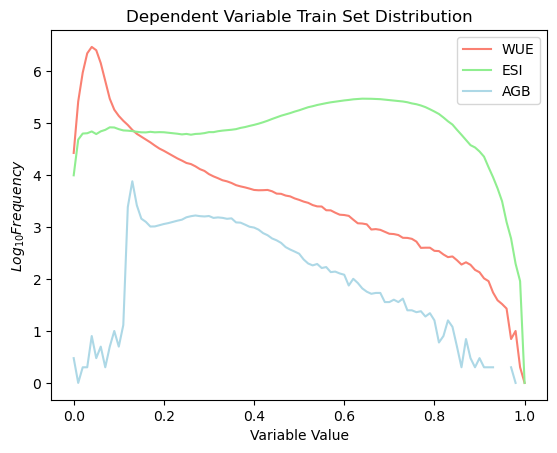

In [14]:
nbins = 200

### dist over train
wrangler.set_mode("train")
ys = [[] for iii in range(3)]

for i in range(len(wrangler)):
    ### val y at batch i
    ys_i = wrangler[i][1]
    for j in range(3):
        for elty in ys_i[j]:
            ys[j].append(elty)
"""
for i in range(3):
    ys[i] = np.arange(500 * (i + 1))/(250 * (i + 1)) """



fig, ax = plt.subplots()

for i in range(3):
    ys[i], b = np.histogram(ys[i], nbins, range=[0, 2])
    ax.plot(np.arange(nbins)/(nbins/2), np.log10(ys[i]), color=colors[i], label=distkey[i])
ax.set(xlabel='Variable Value', ylabel='$Log_{10} Frequency$', title='Dependent Variable Train Set Distribution')
ax.legend(loc="upper right")

/var/folders/kq/5tk5wpns4_lc_q8b14gl0m2h0000gn/T/ipykernel_23701/2329498804.py:20: RuntimeWarning: divide by zero encountered in log10
  ax.plot(np.arange(nbins)/(nbins), np.log10(ys[i]), color=colors[i], label=distkey[i])


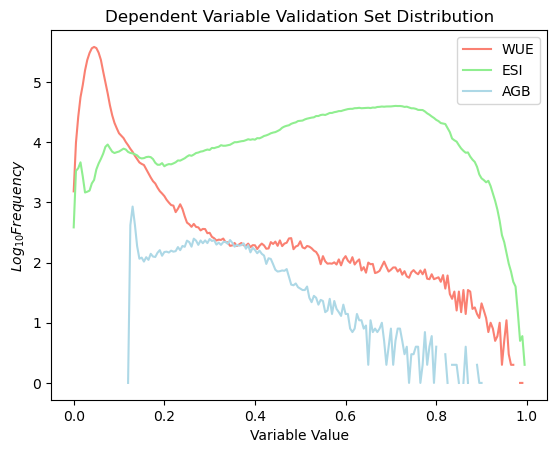

In [15]:
wrangler.set_mode("val")
ys = [[] for iii in range(3)]

for i in range(len(wrangler)):
    ### val y at batch i
    ys_i = wrangler[i][1]
    for j in range(3):
        for elty in ys_i[j]:
            ys[j].append(elty)
"""
for i in range(3):
    ys[i] = np.arange(500 * (i + 1))/(250 * (i + 1)) """



fig, ax = plt.subplots()

for i in range(3):
    ys[i], b = np.histogram(ys[i], nbins, range=[0, 1])
    ax.plot(np.arange(nbins)/(nbins), np.log10(ys[i]), color=colors[i], label=distkey[i])
ax.set(xlabel='Variable Value', ylabel='$Log_{10} Frequency$', title='Dependent Variable Validation Set Distribution')
ax.legend(loc="upper right")

/var/folders/kq/5tk5wpns4_lc_q8b14gl0m2h0000gn/T/ipykernel_23701/2771200118.py:20: RuntimeWarning: divide by zero encountered in log10
  ax.plot(np.arange(nbins)/(nbins/2), np.log10(ys[i]), color=colors[i], label=distkey[i])


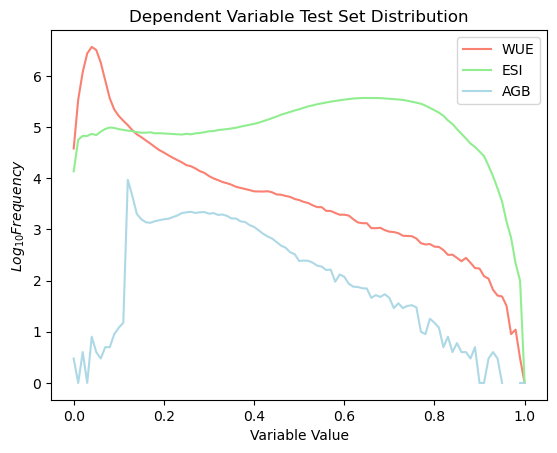

In [16]:
wrangler.set_mode("test")
ys = [[] for iii in range(3)]

for i in range(len(wrangler)):
    ### val y at batch i
    ys_i = wrangler[i][1]
    for j in range(3):
        for elty in ys_i[j]:
            ys[j].append(elty)
"""
for i in range(3):
    ys[i] = np.arange(500 * (i + 1))/(250 * (i + 1)) """



fig, ax = plt.subplots()

for i in range(3):
    ys[i], b = np.histogram(ys[i], nbins, range=[0, 2])
    ax.plot(np.arange(nbins)/(nbins/2), np.log10(ys[i]), color=colors[i], label=distkey[i])
ax.set(xlabel='Variable Value', ylabel='$Log_{10} Frequency$', title='Dependent Variable Test Set Distribution')
ax.legend(loc="upper right")

In [17]:
"""xs = []
print(xs)"""
print(ys[0].shape)

(200,)


In [18]:
nbins = 200

### dist over train
wrangler.set_mode("train")
xs = [[] for ii in range(14)]

for i in range(len(wrangler)):
    ### val y at batch i
    xs_i = wrangler[i][0]
    for j in range(14):
        #print(xs_i)
        for eltx in xs_i[j]:
            xs[j].append(eltx)

In [19]:
for i in range(len(xs)):
    xs[i] = np.array(xs[i])

0.0 1.0 1.0


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


0.0 1.0 1.0


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


0.0 1.0 1.0


...

0.0 1.0 1.0


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


0.0 1.0 1.0


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

0.0 1.0 1.0
0.0 1.0 1.0
0.0 1.0 1.0
0.0 1.0 1.0
0.0 1.0 1.0
0.0 1.0 1.0


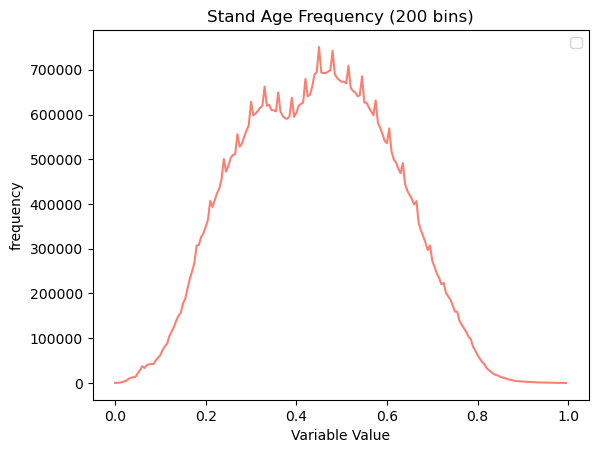

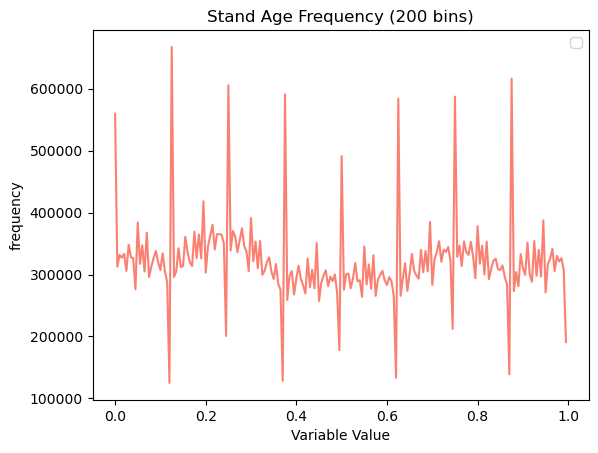

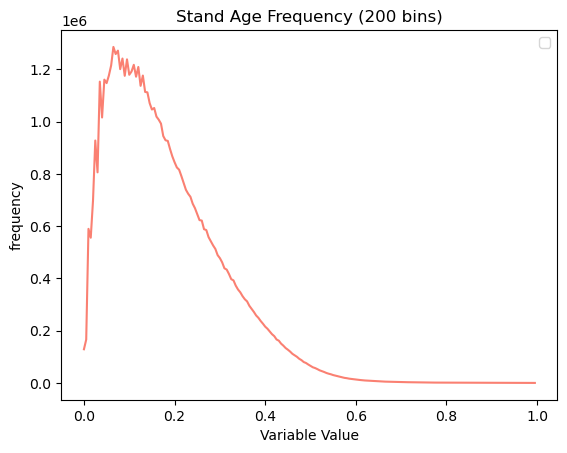

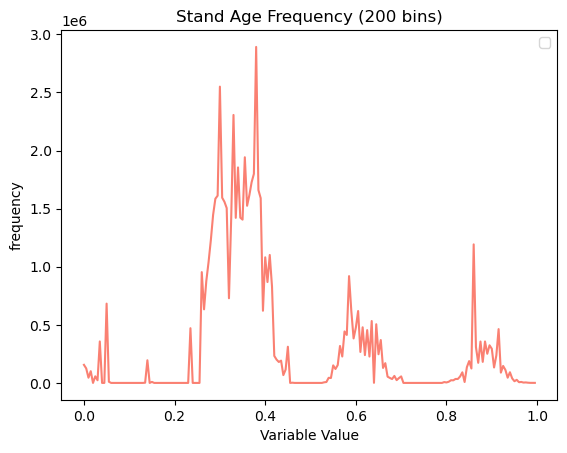

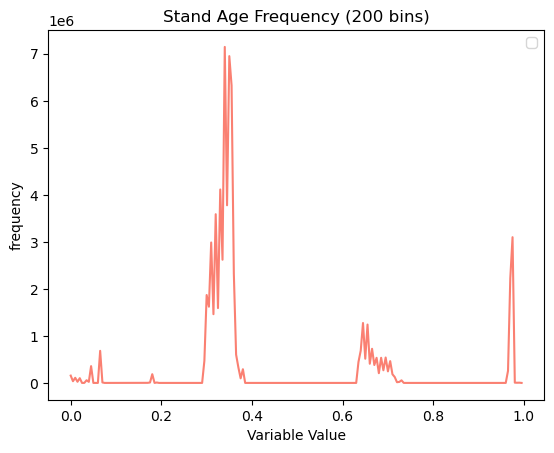

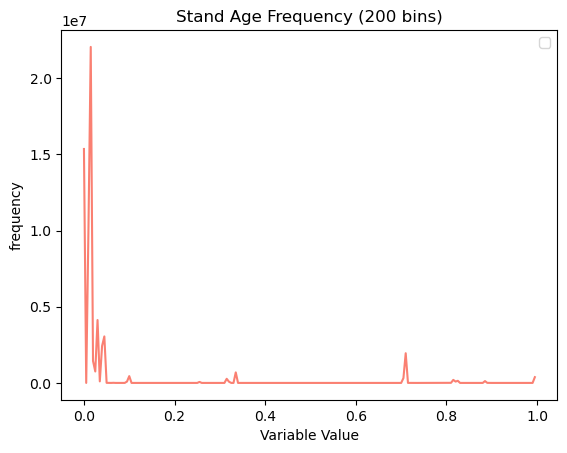

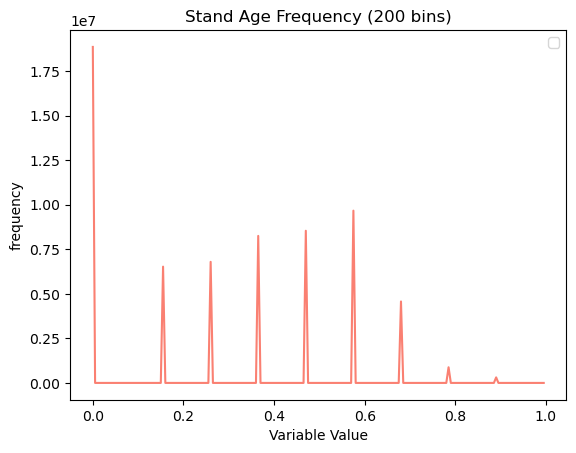

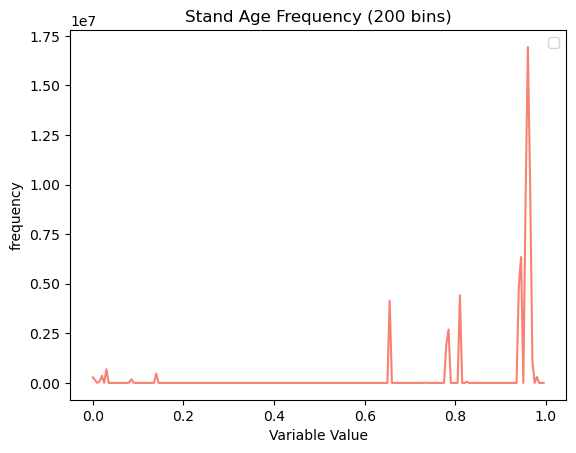

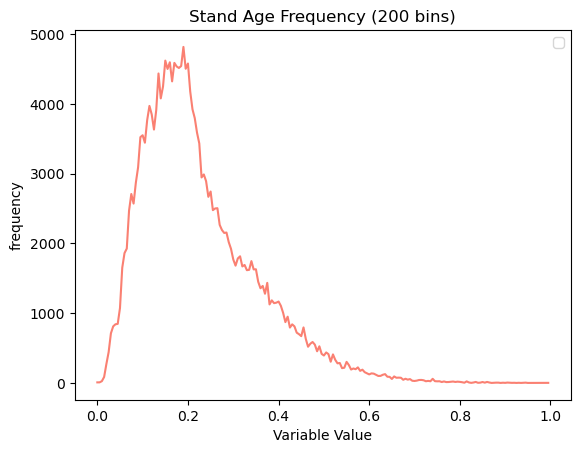

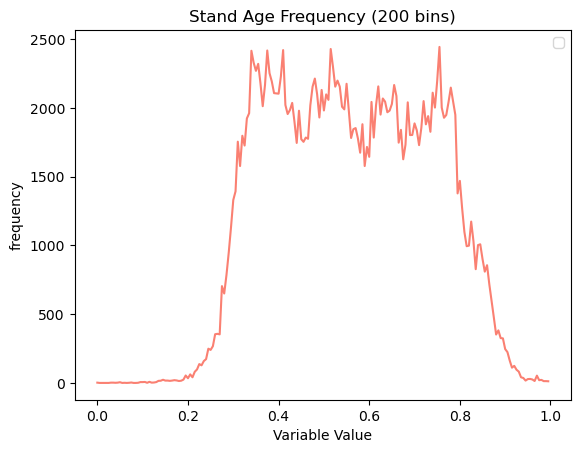

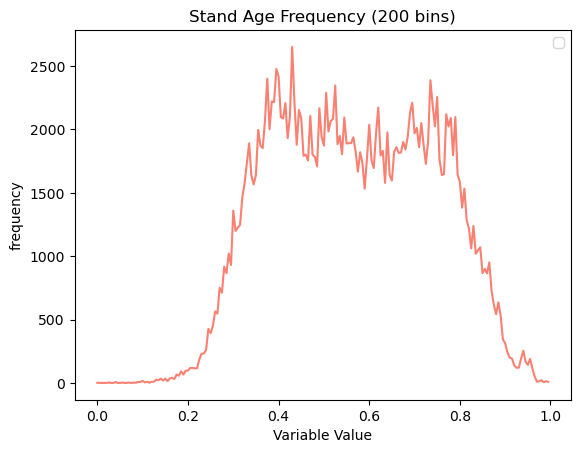

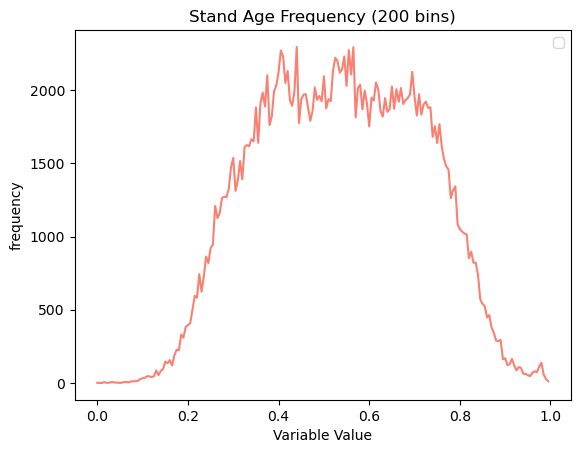

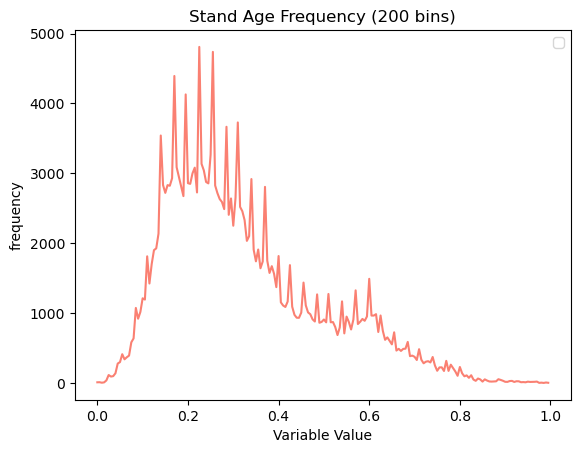

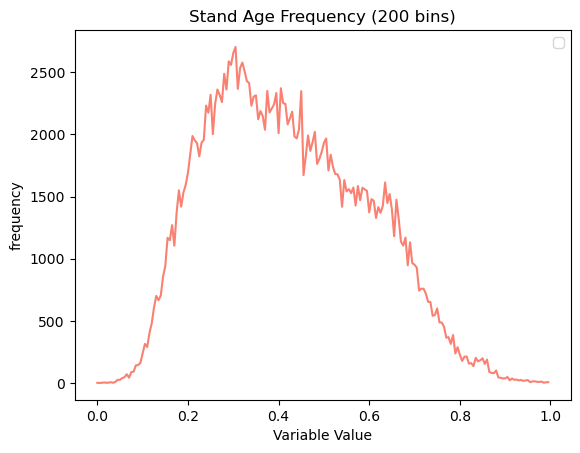

In [20]:

for i in range(len(xs)):
    fig, ax = plt.subplots()

    minvalx = np.min(xs[i])
    maxvalx = np.max(xs[i])
    rangex = maxvalx - minvalx
    print(minvalx, maxvalx, rangex)
    xsi_hist, b = np.histogram(xs[i], nbins, range=[np.min(xs[i]), np.max(xs[i])])
    ax.plot(np.arange(nbins)/(nbins/1), xsi_hist, color=colors[0], )
    ax.set(xlabel='Variable Value', ylabel='frequency', title='Stand Age Frequency (200 bins)')
    ax.legend(loc="upper right")

In [23]:

xsp = [[] for iii in range(3)]
partition = ["train", "val", "test"]
for i in range(len(partition)):
    wrangler.set_mode(partition[i])
    for j in range(len(wrangler)):
        ### val y at batch i
        xsp_j = wrangler[j][0]
        for eltx in xsp_j[-1]:
            xsp[i].append(eltx)


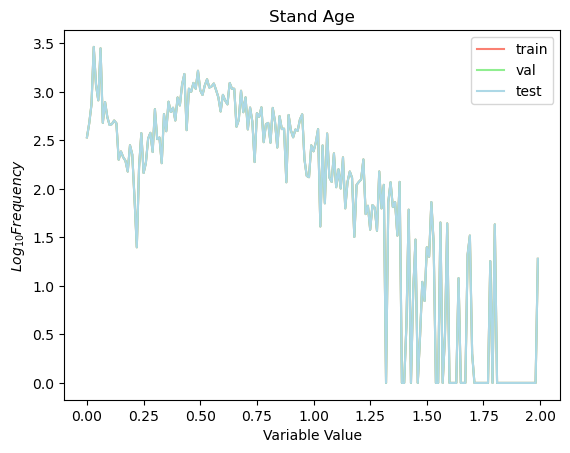

In [25]:
fig, ax = plt.subplots()
nbins = 200
for i in range(3):
    xsp_hi, b = np.histogram(xsp[i], nbins, range=[0, 1])
    ax.plot(np.arange(nbins)/(nbins/2), np.log10(xsp_hi + 1), color=colors[i], label=partition[i])
ax.set(xlabel='Variable Value', ylabel='$Log_{10} Frequency$', title='Stand Age')
ax.legend(loc="upper right")

plt.show()

In [45]:
import h5py

In [48]:
layer_loc =  "../data/ml_sets/pyramid_lf22/layer_14.h5"
h5src = h5py.File(layer_loc,'r')
h5data = h5src["data"]


In [52]:
nph5 = np.array(h5data)
print(len(np.unique(nph5)))

341
